Loading dependencies

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Loading Dataset

In [4]:
# Load our freshly cleaned data
df = pd.read_csv("../data/processed/mtn_customer_churn_cleaned.csv")
sns.set_theme(style="whitegrid")

The Churn Baseline & Customer Demographics

In [5]:
# Calculate precise churn baseline
churn_counts = df['customer_churn_status'].value_counts()
churn_rate = df['customer_churn_status'].value_counts(normalize=True) * 100

print(f"--- Baseline Churn Profile ---")
print(f"Active Customers (no): {churn_counts['no']} ({churn_rate['no']:.2f}%)")
print(f"Churned Customers (yes): {churn_counts['yes']} ({churn_rate['yes']:.2f}%)")


--- Baseline Churn Profile ---
Active Customers (no): 690 (70.84%)
Churned Customers (yes): 284 (29.16%)


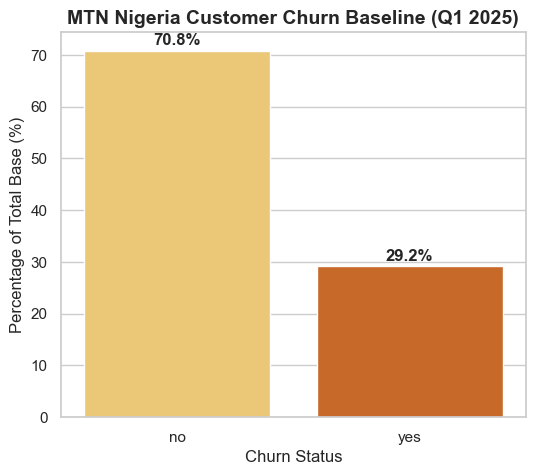

In [8]:
# Plot Churn Distribution
plt.figure(figsize=(6, 5))
sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="YlOrBr")
plt.title("MTN Nigeria Customer Churn Baseline (Q1 2025)", fontsize=14, fontweight='bold')
plt.ylabel("Percentage of Total Base (%)")
plt.xlabel("Churn Status")
for i, v in enumerate(churn_rate.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

Behavioral Segmentations & Financial Value

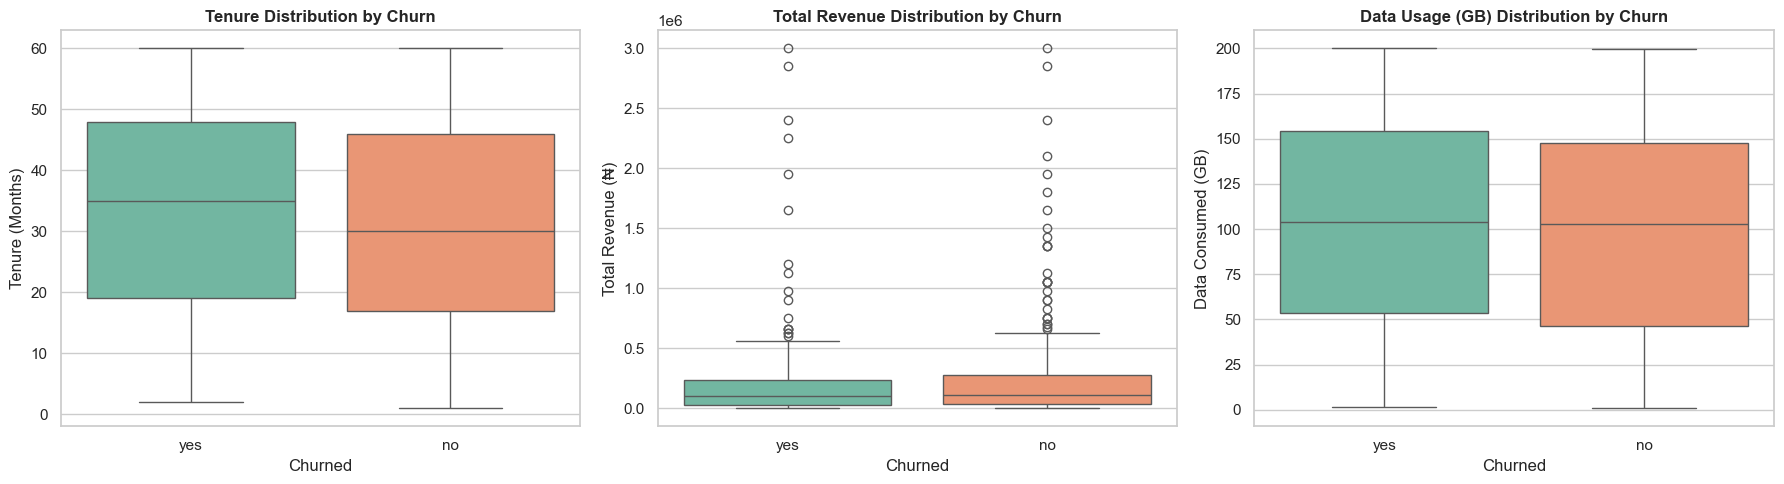

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure vs Churn
sns.boxplot(data=df, x='customer_churn_status', y='customer_tenure_in_months', ax=axes[0], palette="Set2")
axes[0].set_title("Tenure Distribution by Churn", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Churned")
axes[0].set_ylabel("Tenure (Months)")

# Total Revenue vs Churn
sns.boxplot(data=df, x='customer_churn_status', y='total_revenue', ax=axes[1], palette="Set2")
axes[1].set_title("Total Revenue Distribution by Churn", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Churned")
axes[1].set_ylabel("Total Revenue (₦)")

# Data Usage vs Churn
sns.boxplot(data=df, x='customer_churn_status', y='data_usage', ax=axes[2], palette="Set2")
axes[2].set_title("Data Usage (GB) Distribution by Churn", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Churned")
axes[2].set_ylabel("Data Consumed (GB)")

plt.tight_layout()
plt.show()

Sentiment Breaking Points (satisfaction_rate)

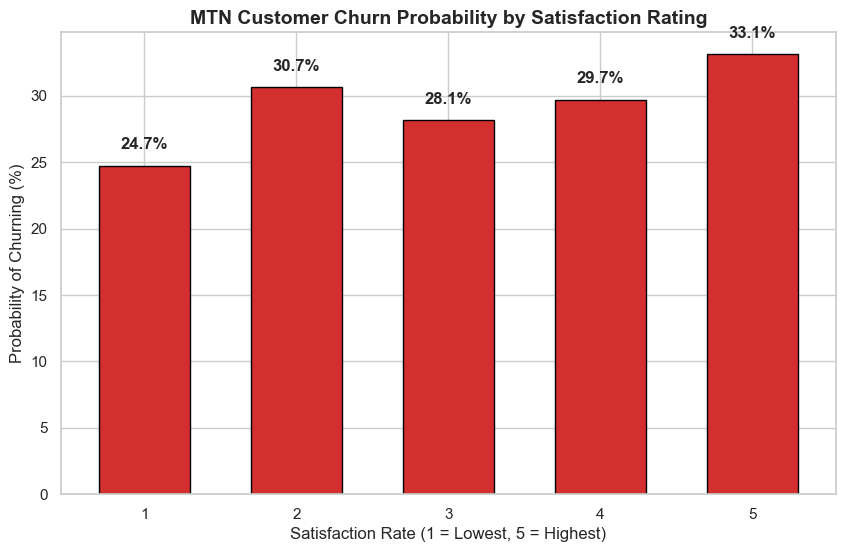

In [14]:
# Compute churn rate per satisfaction score level
sat_churn = df.groupby('satisfaction_rate')['customer_churn_status'].value_counts(normalize=True).unstack().fillna(0) * 100

plt.figure(figsize=(10, 6))
sat_churn['yes'].plot(kind='bar', color='#d32f2f', edgecolor='black', width=0.6)
plt.title("MTN Customer Churn Probability by Satisfaction Rating", fontsize=14, fontweight='bold')
plt.xlabel("Satisfaction Rate (1 = Lowest, 5 = Highest)")
plt.ylabel("Probability of Churning (%)")
plt.xticks(rotation=0)

for i, v in enumerate(sat_churn['yes']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.show()

Diagnostic Analysis: Why Are They Leaving?

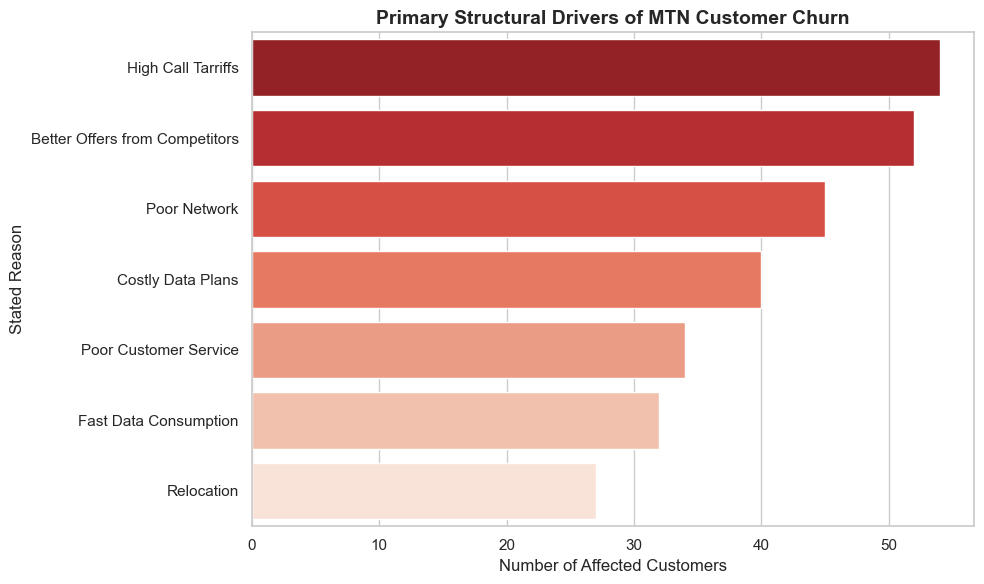

In [15]:
# Filter out active users to inspect churn drivers
churned_df = df[df['customer_churn_status'] == 'yes']
reason_counts = churned_df['reasons_for_churn'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(y=reason_counts.index, x=reason_counts.values, palette="Reds_r")
plt.title("Primary Structural Drivers of MTN Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Number of Affected Customers")
plt.ylabel("Stated Reason")
plt.tight_layout()
plt.show()

Geospatial Churn Concentration (State-by-State Risk)

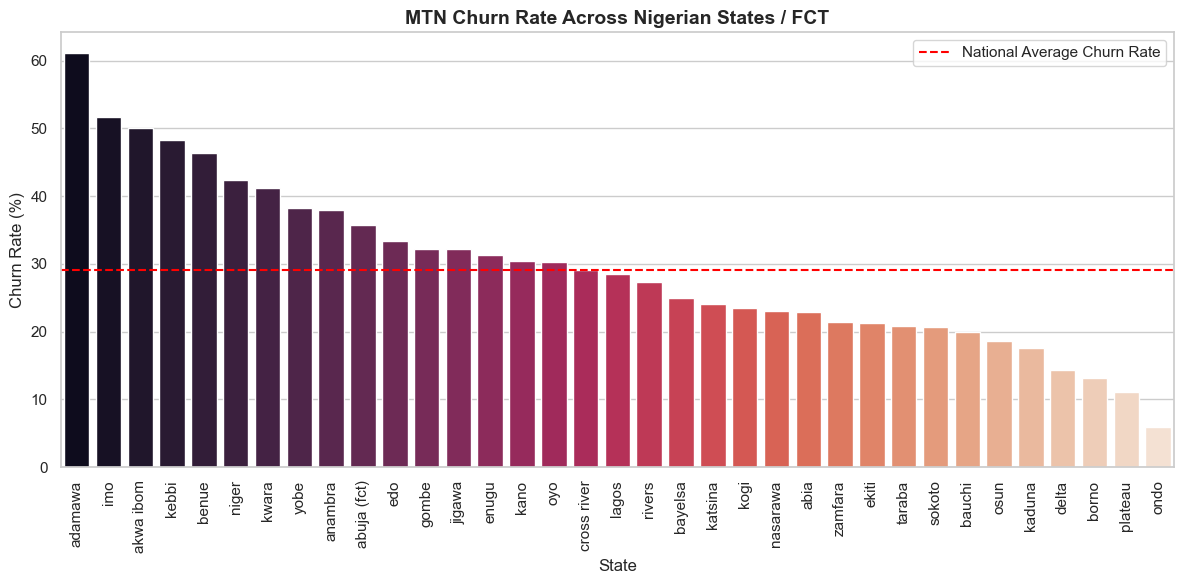

In [16]:
# Calculate churn rate per state
state_churn = df.groupby('state')['customer_churn_status'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_churn.index, y=state_churn.values, palette="rocket")
plt.title("MTN Churn Rate Across Nigerian States / FCT", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=90)
plt.axhline(df['customer_churn_status'].apply(lambda x: 1 if x == 'yes' else 0).mean() * 100, 
            color='red', linestyle='--', label='National Average Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

Product-Market Fit: Device Type vs. Subscription Plan

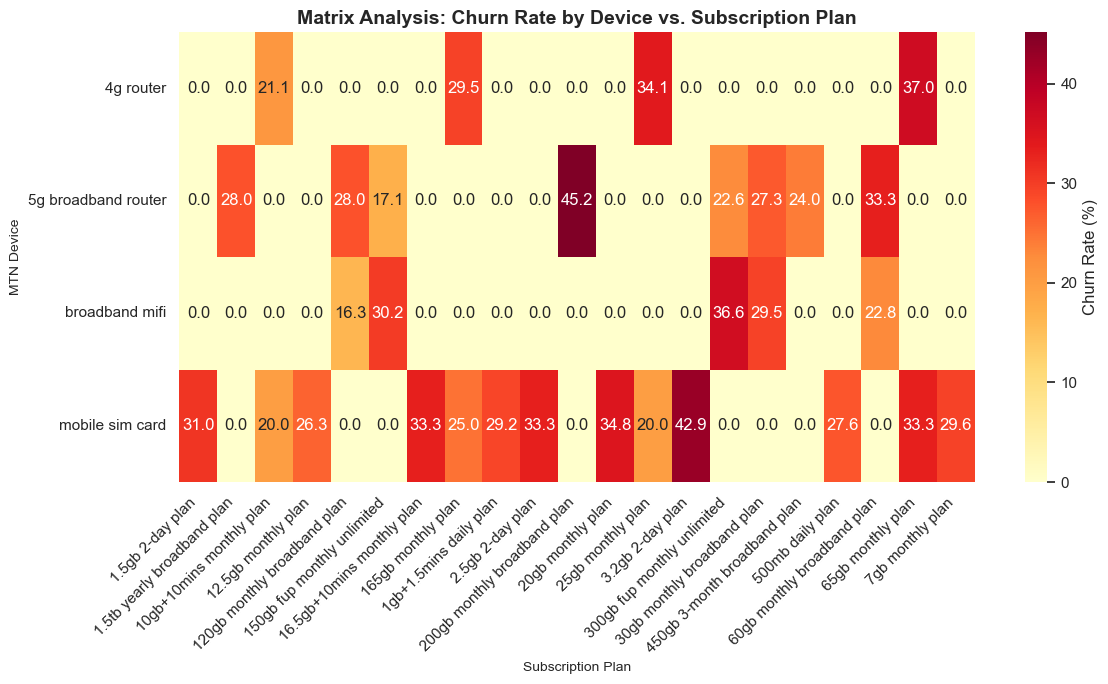

In [27]:
# Heatmap of Churn Rates by Device and Plan Type
pivot_churn = df.pivot_table(
    index='mtn_device', 
    columns='subscription_plan', 
    values='customer_churn_status', 
    aggfunc=lambda x: (x == 'yes').mean() * 100
).fillna(0)

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_churn, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Churn Rate (%)'})

plt.title("Matrix Analysis: Churn Rate by Device vs. Subscription Plan", fontsize=14, fontweight='bold')
plt.xlabel("Subscription Plan", fontsize=10)
plt.ylabel("MTN Device", fontsize=10) 

plt.yticks(rotation=0) 
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Financial Leakage: The "Under-Utilization" Gap

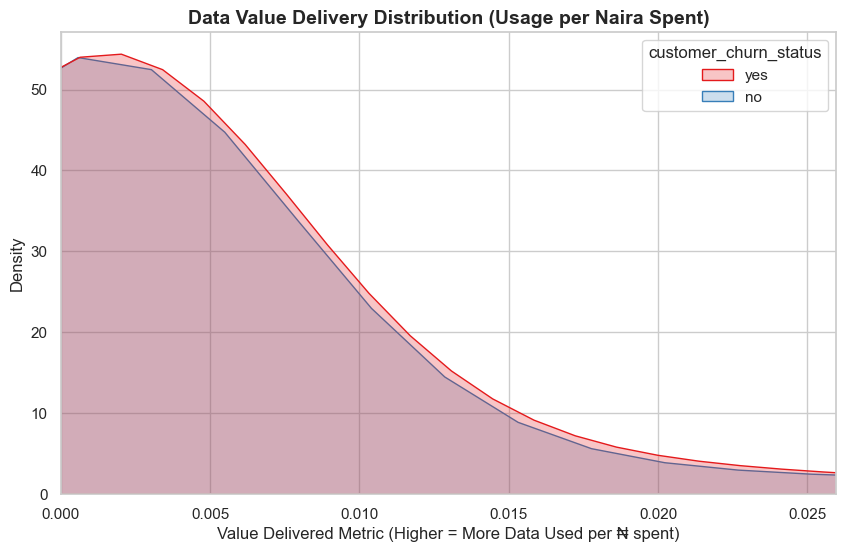

In [26]:
# Engineer temporary feature for visualization
df['value_delivered'] = df['data_usage'] / (df['total_revenue'] + 1)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='value_delivered', hue='customer_churn_status', fill=True, common_norm=False, palette="Set1")
plt.title("Data Value Delivery Distribution (Usage per Naira Spent)", fontsize=14, fontweight='bold')
plt.xlabel("Value Delivered Metric (Higher = More Data Used per ₦ spent)")
plt.ylabel("Density")
plt.xlim(0, df['value_delivered'].quantile(0.95)) 
plt.show()